In [1]:
import matplotlib.pyplot as plt
from OptimalBattery.global_config import repo_dir,save_dir
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
import matplotlib as mpl
mpl.rcParams["pdf.fonttype"] = 42
from scipy.stats import pearsonr
from scipy.stats import sem
from scipy.stats import ttest_rel
from matplotlib.patches import Patch



# simulations

In [2]:
sim_df = pd.read_csv(f"{repo_dir}/eval_tsvs/localization_sim_results.tsv", sep="\t")
# pick a random 100 individuals
unique_ids = sim_df['individual'].unique()
rng = np.random.default_rng(0)
picked_ids = rng.choice(unique_ids, size=1000, replace=False)
sim_df = sim_df[sim_df['individual'].isin(picked_ids)]

In [3]:
# remove type = contrast_adaptive
# sim_df = sim_df[sim_df['type'] != 'contrast_adaptive']

In [4]:
palette = {
    "multitask": "#A34700",              
    "contrast_fixed": "#005788",        
    "contrast_adaptive": "#007656" 
}

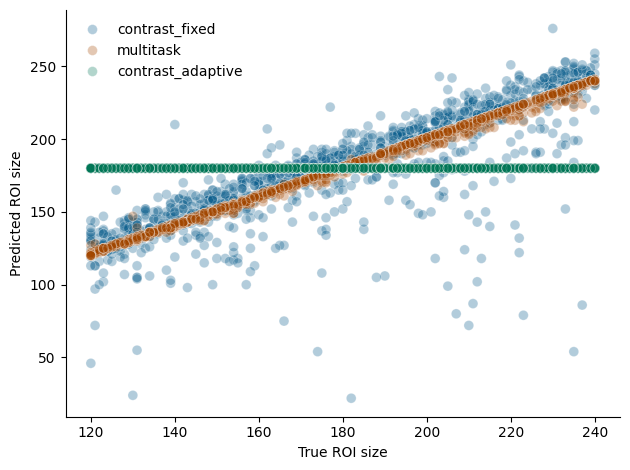

In [5]:
plt.figure()
sns.scatterplot(
    data=sim_df,
    x="true_size", y="predicted_size",
    hue="type", 
    palette=palette, s=50,alpha=0.3,rasterized = True
)

plt.xlabel("True ROI size")
plt.ylabel("Predicted ROI size")
sns.despine()
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(f"{save_dir}/single_vs_multi/sim_size.pdf")
plt.show()

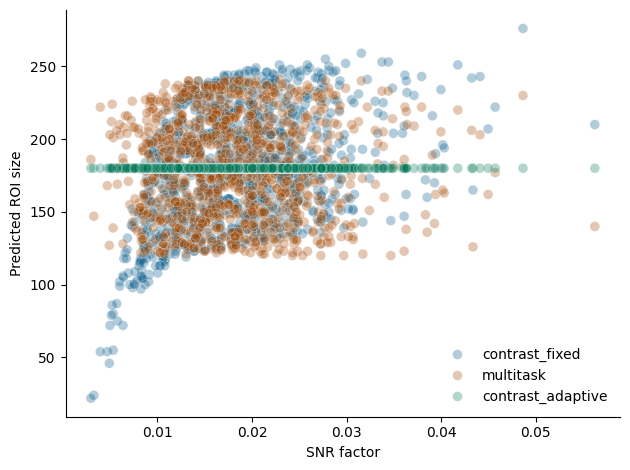

In [6]:
plt.figure()
sns.scatterplot(
    data=sim_df,
    x="snr_factor", y="predicted_size",
    hue="type",
    palette=palette, s=50,alpha = 0.3,rasterized = True
)

plt.xlabel("SNR factor")
plt.ylabel("Predicted ROI size")
sns.despine()
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(f"{save_dir}/single_vs_multi/sim_fSNR.pdf")
plt.show()

In [7]:
df_multi = sim_df[sim_df["type"] == "multitask"]
df_contrast = sim_df[sim_df["type"] == "contrast_fixed"]

r_multi, p_multi = pearsonr(df_multi["predicted_size"], df_multi["snr_factor"])
r_contrast, p_contrast = pearsonr(df_contrast["predicted_size"], df_contrast["snr_factor"])



print("Multi-task localizer:")
print(f"  r = {r_multi:.3f}, p = {p_multi:.3e}")

print("Single-contrast (T) localizer:")
print(f"  r = {r_contrast:.3f}, p = {p_contrast:.3e}")


Multi-task localizer:
  r = -0.003, p = 9.364e-01
Single-contrast (T) localizer:
  r = 0.408, p = 1.890e-41


In [8]:
sub_mean = sim_df.groupby("individual")["accuracy"].transform("mean")

global_mean = sim_df["accuracy"].mean()


sim_df["accuracy_adj"] = sim_df["accuracy"] - sub_mean + global_mean

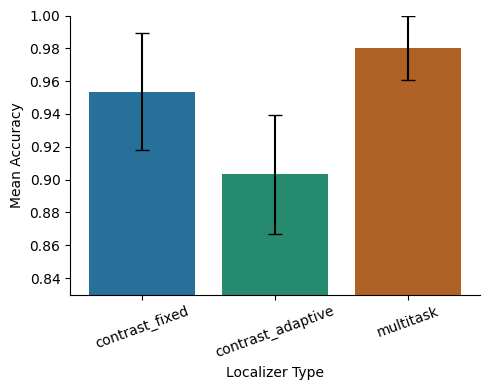

In [11]:

order = ["contrast_fixed", "contrast_adaptive", "multitask"]
means = [
    sim_df.loc[sim_df["type"] == t, "accuracy_adj"].mean()
    for t in order
]
sds = [
    sim_df.loc[sim_df["type"] == t, "accuracy_adj"].std(ddof=1)
    for t in order
]
colors = [palette[t] for t in order]

fig, ax = plt.subplots(figsize=(5, 4))
x = np.arange(len(order))
ax.bar(
    x,
    means,
    yerr=sds,
    capsize=5,
    color=colors,
    alpha=0.85
)

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=20)
ax.set_ylabel("Mean Accuracy")
ax.set_xlabel("Localizer Type")

ax.set_ylim(0.83, 1.0)

# seaborn-like cleanup
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(f"{save_dir}/single_vs_multi/sim_accuracy.pdf", bbox_inches="tight")
plt.show()


In [11]:
acc_single_fixed = sim_df[sim_df["type"] == "contrast_fixed"]["accuracy_adj"]
acc_multi  = sim_df[sim_df["type"] == "multitask"]["accuracy_adj"]
acc_single_adaptive  = sim_df[sim_df["type"] == "contrast_adaptive"]["accuracy_adj"]

In [12]:
tval, pval = ttest_rel(acc_multi, acc_single_fixed)
print("t =", tval, "   p =", pval)
tval, pval = ttest_rel(acc_multi, acc_single_adaptive)
print("t =", tval, "   p =", pval)

t = 18.82823676378933    p = 6.470147339367955e-68
t = 52.674410938164165    p = 1.4536099529691602e-290


# fMRI

In [13]:
real_df = pd.read_csv(f"{repo_dir}/eval_tsvs/localization_real_contrasts.tsv", sep="\t")


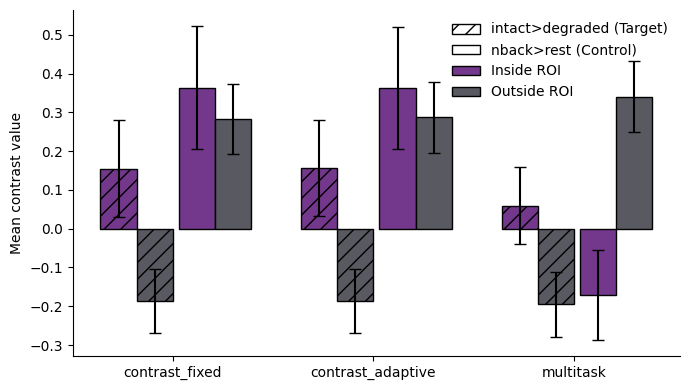

In [14]:
locs = ["contrast_fixed", "contrast_adaptive", "multitask"]
contrasts = ["intact>degraded", "nback>rest"]
regions = ["Inside", "Outside"]

colors = {"Inside": (0.45,0.22,0.55), "Outside": (0.35,0.35,0.38)}
hatch = {"intact>degraded": "//", "nback>rest": ""}

# reshape into long format 
rows = []
for _, row in real_df.iterrows():
    rows.append([row.localizer, row.contrast, "Inside", row.inside])
    rows.append([row.localizer, row.contrast, "Outside", row.outside])

long_df = pd.DataFrame(rows, columns=["localizer","contrast","region","value"])

# compute mean + SEM
plot_rows = []
for L in locs:
    for R in regions:
        for C in contrasts:
            vals = long_df[
                (long_df.localizer == L) &
                (long_df.region == R) &
                (long_df.contrast == C)
            ]["value"].values

            plot_rows.append([L, R, C,
                np.nanmean(vals),
                sem(vals, nan_policy="omit")
            ])

plot_df = pd.DataFrame(plot_rows, columns=["Loc","Reg","Con","Mean","SEM"])

# ------------ plot ------------
fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(locs))
w = 0.18

# 🟣 very small spacing
gap = 0.03

offsets = {
    ("Inside",  "intact>degraded"): -1.5*w,
    ("Outside", "intact>degraded"): -0.5*w,

    ("Inside",  "nback>rest"):       0.5*w + gap,
    ("Outside", "nback>rest"):       1.5*w + gap,
}

for R in regions:
    for C in contrasts:
        sub = plot_df[(plot_df.Reg==R)&(plot_df.Con==C)]
        ax.bar(
            x + offsets[(R, C)],
            sub["Mean"],
            w,
            color=colors[R],
            edgecolor="black",
            hatch=hatch[C],
            yerr=sub["SEM"],
            capsize=4
        )

ax.set_xticks(x)
ax.set_xticklabels(locs)
ax.set_ylabel("Mean contrast value")
sns.despine()

# Legend
legend_elements = [
    Patch(facecolor='white', edgecolor='black', hatch='//', label='intact>degraded (Target)'),
    Patch(facecolor='white', edgecolor='black', hatch='',   label='nback>rest (Control)'),
    Patch(facecolor=colors["Inside"], edgecolor='black',    label='Inside ROI'),
    Patch(facecolor=colors["Outside"], edgecolor='black',   label='Outside ROI'),
]
ax.legend(handles=legend_elements, frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig(f"{save_dir}/single_vs_multi/language_contrasts.pdf")
plt.show()


ttests

In [15]:
locs = ["multitask","contrast_fixed", "contrast_adaptive"]
pairs = [
    ("contrast_fixed", "contrast_adaptive"),
    ("multitask","contrast_fixed" ),
    ("multitask","contrast_adaptive")
]

contrasts = ["intact>degraded", "nback>rest"]
regions = ["Inside", "Outside"]

rows = []

for C in contrasts:
    for R in regions:
        for L1, L2 in pairs:

            v1 = long_df[
                (long_df.localizer==L1) &
                (long_df.contrast==C) &
                (long_df.region==R)
            ]["value"].values

            v2 = long_df[
                (long_df.localizer==L2) &
                (long_df.contrast==C) &
                (long_df.region==R)
            ]["value"].values

            t, p = ttest_rel(v1, v2)

            rows.append([C, R, f"{L1} vs {L2}", t, p])

df_compare = pd.DataFrame(rows, columns=[
    "Contrast", "Region", "Comparison", "t_value", "p_value"
])

df_compare

,Contrast,Region,Comparison,t_value,p_value
0,intact>degraded,Inside,contrast_fixed vs contrast_adaptive,-0.134637,0.894689
1,intact>degraded,Inside,multitask vs contrast_fixed,-1.086588,0.294372
2,intact>degraded,Inside,multitask vs contrast_adaptive,-1.129859,0.276280
3,intact>degraded,Outside,contrast_fixed vs contrast_adaptive,0.521812,0.609421
4,intact>degraded,Outside,multitask vs contrast_fixed,-1.240050,0.234006
5,intact>degraded,Outside,multitask vs contrast_adaptive,-1.064507,0.303936
6,nback>rest,Inside,contrast_fixed vs contrast_adaptive,0.102376,0.919814
7,nback>rest,Inside,multitask vs contrast_fixed,-4.761038,0.000252
8,nback>rest,Inside,multitask vs contrast_adaptive,-4.525192,0.000403
9,nback>rest,Outside,contrast_fixed vs contrast_adaptive,-1.431348,0.172836
